In [ ]:
"""
Created on: 18-08-2026

@author B.A. Sturre

PyTorch tutorial 
https://www.youtube.com/watch?v=c36lUUr864M 
"""

import matplotlib.pyplot as plt
import sys 
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.tensorboard import SummaryWriter
import torchvision
from torchvision import transforms

## Tensorboard

The tensorboard can be used to visualize and analyze our training pipeline. https://www.tensorflow.org/tensorboard 

To run tensorboard, we use the following command in the terminal: 

`tensorboard --logdir=directory`

with this as the directory: 

In [ ]:
import os 
print(os.path.abspath('runs'))

In [16]:
# create tensorboard writer
writer = SummaryWriter('runs/mnist')

# device configuration: run on gpu if supported (it's not)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# hyper parameters 
input_size = 784  # 28x28 flattened
hidden_size = 100
num_classes = 10  # 10 digits (0-9)
num_epochs = 2 
batch_size = 100
learning_rate = 0.001

# MNIST dataset 
train_dataset = torchvision.datasets.MNIST('./data', train=True, transform=transforms.ToTensor(), download=True)
test_dataset = torchvision.datasets.MNIST('./data', train=False, transform=transforms.ToTensor())

# data loaders
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

torch.Size([100, 1, 28, 28]) torch.Size([100])


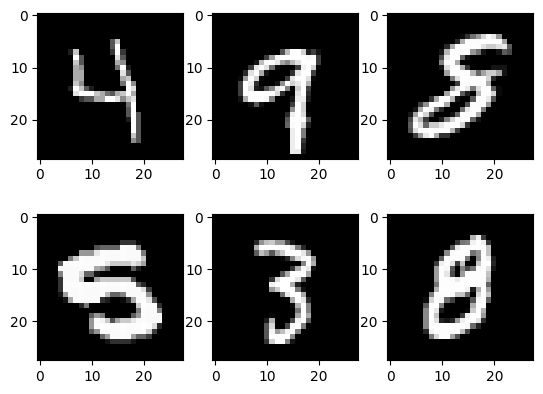

In [17]:
# example
examples = iter(train_loader)
samples, labels = next(examples)
print(samples.shape, labels.shape)

for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(samples[i][0], cmap='gray')

# add images to the tensorboard
img_grid = torchvision.utils.make_grid(samples)
writer.add_image('mnist_images', img_grid)
writer.flush()
writer.close()

In [18]:
class NeuralNet(nn.Module): 
    def __init__(self, input_size, hidden_size, num_classes): 
        super(NeuralNet, self).__init__()
        self.linear1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.linear2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x): 
        out = self.linear1(x)
        out = self.relu(out)
        out = self.linear2(out)
        # no softmax because we will apply CEL
        return out

model = NeuralNet(input_size, hidden_size, num_classes)

# loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate)

# add to tensor board
writer.add_graph(model, samples.reshape(-1, 28*28).to(device))

# parameters to add to tensorboard
running_loss = 0.0
running_correct = 0

# training loop
n_total_steps = len(train_loader)
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):
        # reshaping images: 100, 1, 28, 28 -> 100, 784
        images = images.reshape(-1, 28*28).to(device)
        labels = labels.to(device)

        # forward 
        outputs = model(images)
        loss = criterion(outputs, labels)

        # backward 
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        running_correct += (predicted == labels).sum().item()

        if (i+1)%100 == 0: 
            print(f'epoch {epoch+1} / {num_epochs}, step {i+1}/{n_total_steps}, loss = {loss.item():.4f}')
            writer.add_scalar('training loss', running_loss/100, epoch * n_total_steps + i)            
            writer.add_scalar('accuracy', running_correct/100, epoch * n_total_steps + i)
            running_loss = 0.0
            running_correct = 0 

epoch 1 / 2, step 100/600, loss = 0.3916
epoch 1 / 2, step 200/600, loss = 0.2942
epoch 1 / 2, step 300/600, loss = 0.3309
epoch 1 / 2, step 400/600, loss = 0.2458
epoch 1 / 2, step 500/600, loss = 0.1670
epoch 1 / 2, step 600/600, loss = 0.3176
epoch 2 / 2, step 100/600, loss = 0.2495
epoch 2 / 2, step 200/600, loss = 0.1840
epoch 2 / 2, step 300/600, loss = 0.3773
epoch 2 / 2, step 400/600, loss = 0.2147
epoch 2 / 2, step 500/600, loss = 0.2062
epoch 2 / 2, step 600/600, loss = 0.1830


In [19]:
# lists for precision-recall curve
labs = []
preds = []

# test 
with torch.no_grad(): 
    n_correct = 0
    n_samples = 0 
    for images, labels in test_loader: 
        # reshaping images: 100, 1, 28, 28 -> 100, 784
        images = images.reshape(-1, 28*28).to(device)
        labels = labels.to(device)

        # calculating predictions 
        outputs = model(images)
        _, predictions = torch.max(outputs, 1)

        n_samples += labels.shape[0]
        n_correct += (predictions == labels).sum().item()

        # getting the probabilies
        class_preds = [F.softmax(output, dim=0) for output in outputs]

        labs.append(predictions)
        preds.append(class_preds)

    labs = torch.cat(labs)  # concatenate all elements of list into 1d tensor
    preds = torch.cat([torch.stack(batch) for batch in preds])  # shape 10000x10

    acc = 100.0 * n_correct / n_samples 
    print(f'accuracy = {acc:.2f}%')

    # pr curve
    classes = range(10)
    for i in classes: 
        labels_i = labs == i 
        preds_i = preds[:, i]
        writer.add_pr_curve(str(i), labels_i, preds_i, global_step=0)
        writer.close()

accuracy = 95.40%
